In [1]:
import astropy.coordinates as coord
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib as mlp
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.ticker import FormatStrFormatter
from astropy.coordinates import SkyCoord
import astropy.units as units

In [3]:
# Data
fname = 'ztf_field_corners.csv'
data = pd.read_csv(fname)

data_cuts = pd.read_csv('cuts.csv') # every 7th field
field_stats = pd.read_csv('field_sizes.txt', header=None, delim_whitespace=True, names=['file', 'n'])

/tmp/ipykernel_4153/1177848562.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  field_stats = pd.read_csv('field_sizes.txt', header=None, delim_whitespace=True, names=['file', 'n'])


In [4]:
# Make column with field ID
field_stats['FID'] = [int(field_stats.iloc[i]['file'][field_stats['file'].values[i].index('_') + 1:
                           field_stats['file'].values[i].index('.')]) 
                     for i in range(field_stats.shape[0])]

In [5]:
# Data filtering
coord_corners = data[data['field'].isin(field_stats['FID'])]
coord_corners = coord_corners.reset_index(drop=True)

In [6]:
# Adding column n, comparing field with FID from field_stats
n = []
for obj in coord_corners['field'].values:
    mask_field = field_stats['FID'].values == obj
    if mask_field.any():
        n_value = field_stats[mask_field]['n'].values[0]
    else:
        n_value = 0  # any value
    n.append(n_value)

coord_corners['n'] = n

In [7]:
# Coordinate transformation
names = ['l1', 'b1', 'l2', 'b2', 'l3', 'b3', 'l4', 'b4']
data_lb = []
c = 30

for j in range(coord_corners.shape[0]):
    line = []
    for i in range(1, 5):
        f1 = SkyCoord((coord_corners.iloc[j]['ra' + str(i)] + c) * units.degree, 
                      coord_corners.iloc[j]['dec' + str(i)] * units.degree, 
                      unit='degree', frame='icrs')
        l1 = -f1.ra.wrap_at(180 * units.deg).radian
        b1 = f1.dec.radian
        # l1 = f1.galactic.l.radian
        # b1 = f1.galactic.b.radian
        line.append(l1)
        line.append(b1)
    data_lb.append(line)
    
df = pd.DataFrame(data_lb, columns=names)
coord_corners = pd.concat([coord_corners, df], axis=1)

/tmp/ipykernel_4153/1585898167.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian-(c*np.pi/180),
/tmp/ipykernel_4153/1585898167.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  im_m = plt.scatter(-m31.icrs.ra.wrap_at(180 * units.deg).radian,


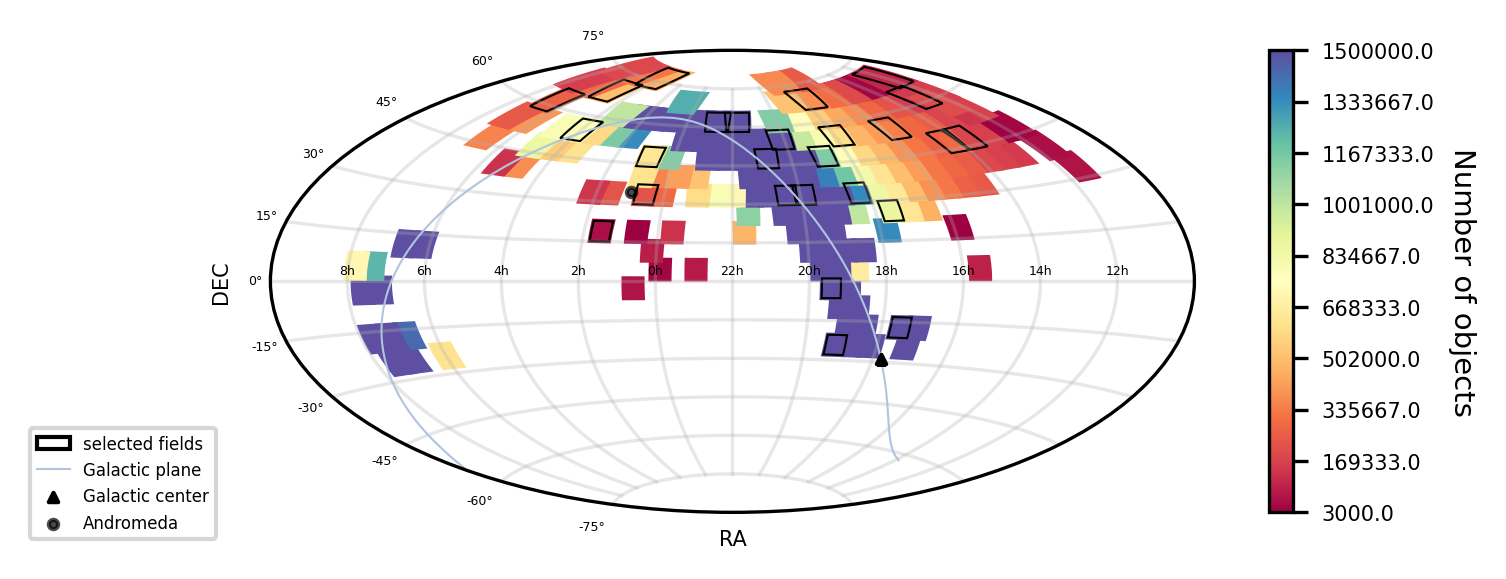

In [15]:
# Plotting
cvals = [3000, 1500000]
norm = Normalize(min(cvals), max(cvals))
cmap = plt.cm.Spectral

fig, ax = plt.subplots(figsize=(5, 2), dpi=300, subplot_kw={'projection': 'aitoff'})

for j in range(coord_corners.shape[0]):
    y = np.array([
        [coord_corners.iloc[j]['l1'], coord_corners.iloc[j]['b1']], 
        [coord_corners.iloc[j]['l2'], coord_corners.iloc[j]['b2']], 
        [coord_corners.iloc[j]['l3'], coord_corners.iloc[j]['b3']], 
        [coord_corners.iloc[j]['l4'], coord_corners.iloc[j]['b4']]
    ])
    rgb = cmap(norm(coord_corners.iloc[j]['n']))[:3]
    color = mcolors.rgb2hex(rgb)
    p = Polygon(y, color=color, alpha=1, zorder=-1)
    ax.add_patch(p)
    
    if coord_corners.iloc[j]['field'] in data_cuts['FID'].values:
        p1 = Polygon(y, edgecolor='black', fill=None, alpha=1, zorder=1, linewidth=0.5)
        ax.add_patch(p1)

ax.set_xticklabels(['8h', '6h', '4h', '2h', '0h', '22h', '20h', '18h', '16h', '14h', '12h'])

pl1 = Polygon([[None, None], [None, None], [None, None], [None, None]], 
              fill=None, alpha=1, edgecolor='black', label='selected fields')
ax.add_patch(pl1)

# add galactic plane
g_p = SkyCoord(l=np.linspace(-50, 296.976, 100)*units.degree, 
               b=np.zeros(100)*units.degree, frame = 'galactic')
plt.plot(-g_p.icrs.ra.wrap_at(180*units.deg).radian-(c*np.pi/180), 
         g_p.icrs.dec.radian, linestyle='-', 
         linewidth = 0.5, color = 'lightsteelblue', label = 'Galactic plane')

# add galactic center
gc = SkyCoord(l=0*units.degree, b=0*units.degree, frame='galactic')
im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian-(c*np.pi/180), 
                   gc.icrs.dec.radian, cmap='PuBu', s=5 ,marker='^',
                   edgecolor=None, zorder=5, color='black', label='Galactic center')

# add M31
m31 = SkyCoord(l=(121.174329 + c)*units.degree, 
               b=(-21.573309)*units.degree, frame='galactic')
im_m = plt.scatter(-m31.icrs.ra.wrap_at(180 * units.deg).radian, 
                   m31.icrs.dec.radian, cmap='PuBu', s=5,
                   edgecolor=None, zorder=5, color = 'black', label='Andromeda', 
                   alpha =0.7)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ticks = np.linspace(cvals[0], cvals[1], 10).round()
cbar = plt.colorbar(sm, ax=ax, ticks=ticks, format=FormatStrFormatter("%.1f"))
cbar.set_label("Number of objects", fontsize=7, rotation=270, labelpad=10)
cbar.ax.tick_params(labelsize=5)
cbar.ax.yaxis.get_offset_text().set_fontsize(5)

plt.tick_params(axis='both', pad=100, labelsize=3)
plt.grid(zorder=0.5, alpha=0.3)
plt.xlabel('RA', fontsize=5)
plt.ylabel('DEC', fontsize=5)
plt.legend(loc=4, fontsize=2.5)
plt.legend(bbox_to_anchor=(-0.05, -0.075), loc='lower right', fontsize=4)
plt.subplots_adjust(left=0.0, right=1)
#plt.savefig('../plots/artefact_fields.pdf')

In [9]:
# Sorting by N_obs
coord_corners = coord_corners.sort_values(by='n', ascending=False)

# Every 7th
selected_fields = coord_corners.iloc[::7]

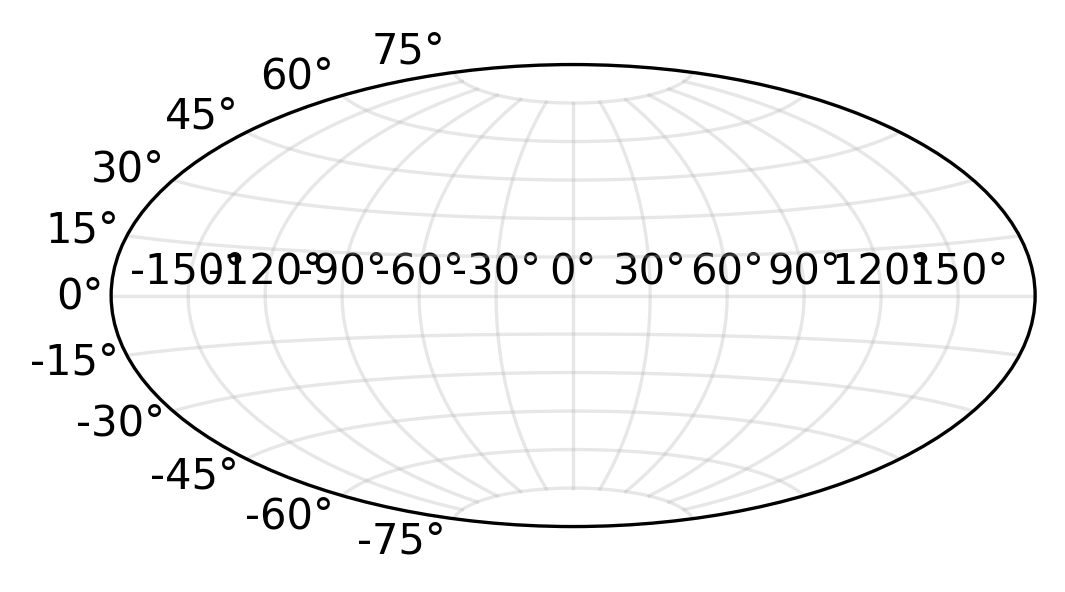

In [2]:
fig, ax = plt.subplots(figsize=(5, 2), dpi=300, subplot_kw={'projection': 'aitoff'})
plt.grid(zorder=0.5, alpha=0.3)